# Cluster analysis

- compare embeddings on Emotion, Period, Format and PoetTop20
- save summary tables
- do a simple top-level tag analysis for the best 3 embeddings


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, pairwise_distances, silhouette_score

# Load metadata and embeddings

make sure SNLP-Project-main.zip is uploaded into /content/

In [6]:
import zipfile
import os

zip_file_path = '/content/SNLP-Project-main.zip'

if os.path.exists(zip_file_path):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall('.')
    print(f'Successfully unzipped {zip_file_path} to the current directory.')
else:
    print(f'The file {zip_file_path} does not exist.')

Successfully unzipped /content/SNLP-Project-main.zip to the current directory.


In [7]:
EMBEDDING_NAME_DICT = {
    'baseline' : 'baseline',
    'w2v_d100_w5_cbow_avg' : 'word-cbow-avg',
    'w2v_d100_w5_cbow_idf' : 'word-cbow-idf',
    'w2v_d100_w5_cbow_sif' : 'word-cbow-sif',
    'w2v_d100_w5_sg_avg' : 'word-sg-avg',
    'w2v_d100_w5_sg_idf' : 'word-sg-idf',
    'w2v_d100_w5_sg_sif' : 'word-sg-sif',
    'd2v_line_d100_w5_dm': 'line-dm',
    'd2v_line_d100_w5_dbow': 'line-dbow',
    'd2v_poem_d100_w5_dm': 'poem-dm',
    'd2v_poem_d100_w5_dbow': 'poem-dbow'

}

In [11]:
%cd /content/SNLP-Project-main/Embeddings
embeddings_dir = Path('.')
filtered_embeddings_dir = embeddings_dir / 'filtered_embeddings'
results_dir = embeddings_dir / 'results' / 'cluster_analysis'
projection_dir = results_dir / 'pca_projections'
results_dir.mkdir(parents=True, exist_ok=True)
projection_dir.mkdir(parents=True, exist_ok=True)

data = pd.read_csv(embeddings_dir / 'filtered_poems.csv', engine='python')
embedding_files = sorted(filtered_embeddings_dir.glob('*.npy'))

embeddings = {}
for path in embedding_files:
    arr = np.load(path).astype(np.float64)
    norms = np.linalg.norm(arr, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    embeddings[path.stem] = arr / norms

print(f'Poems: {len(data)}')
print(f'Embeddings: {len(embeddings)}')
print(sorted(embeddings.keys()))


/content/SNLP-Project-main/Embeddings
Poems: 2853
Embeddings: 11
['baseline', 'd2v_line_d100_w5_dbow', 'd2v_line_d100_w5_dm', 'd2v_poem_d100_w5_dbow', 'd2v_poem_d100_w5_dm', 'w2v_d100_w5_cbow_avg', 'w2v_d100_w5_cbow_idf', 'w2v_d100_w5_cbow_sif', 'w2v_d100_w5_sg_avg', 'w2v_d100_w5_sg_idf', 'w2v_d100_w5_sg_sif']


# Prepare tasks

In [12]:
top_20_poets = data['Poet'].value_counts().head(20).index

tasks = {
    'Emotion': {
        'mask': np.ones(len(data), dtype=bool),
        'labels': data['Emotion'].astype(str).to_numpy(),
        'n_clusters': data['Emotion'].nunique(),
    },
    'Period': {
        'mask': np.ones(len(data), dtype=bool),
        'labels': data['Period'].astype(str).to_numpy(),
        'n_clusters': data['Period'].nunique(),
    },
    'Format': {
        'mask': np.ones(len(data), dtype=bool),
        'labels': data['Format'].astype(str).to_numpy(),
        'n_clusters': data['Format'].nunique(),
    },
    'PoetTop20': {
        'mask': data['Poet'].isin(top_20_poets).to_numpy(),
        'labels': data.loc[data['Poet'].isin(top_20_poets), 'Poet'].astype(str).to_numpy(),
        'n_clusters': 20,
    },
}

task_summary_rows = []
for task_name, task in tasks.items():
    labels = pd.Series(task['labels'])
    task_summary_rows.append({
        'task': task_name,
        'n_samples': len(labels),
        'n_clusters': task['n_clusters'],
        'largest_class_size': int(labels.value_counts().max()),
        'smallest_class_size': int(labels.value_counts().min()),
    })

task_summary = pd.DataFrame(task_summary_rows)
task_summary


,task,n_samples,n_clusters,largest_class_size,smallest_class_size
0,Emotion,2853,6,820,210
1,Period,2853,6,894,19
2,Format,2853,4,1428,68
3,PoetTop20,536,20,51,21


# Helper functions

In [13]:
TOP_LEVEL_TAGS = [
    'Living',
    'Love',
    'Nature',
    'Activities',
    'Arts & Sciences',
    'Relationships',
    'Social Commentaries',
    'Religion',
    'The Body',
    'Mythology & Folklore',
]

def make_agglomerative(n_clusters):
    try:
        return AgglomerativeClustering(n_clusters=n_clusters, linkage='average', metric='cosine')
    except TypeError:
        return AgglomerativeClustering(n_clusters=n_clusters, linkage='average', affinity='cosine')

def safe_silhouette(matrix, cluster_labels):
    unique = np.unique(cluster_labels)
    if len(unique) < 2 or len(unique) >= len(cluster_labels):
        return np.nan
    return silhouette_score(
        matrix,
        cluster_labels,
        metric='cosine',
        sample_size=min(1500, len(cluster_labels)),
        random_state=42,
    )

def parse_top_level_tags(raw_tags):
    tokens = [token.strip() for token in str(raw_tags).split(',') if token.strip()]
    tags = [tag for tag in TOP_LEVEL_TAGS if tag in tokens]
    if len(tags) == 0:
        tags = ['Other']
    return tags

def mean_within_cluster_jaccard(tag_matrix, cluster_labels):
    total_similarity = 0.0
    total_pairs = 0
    for cluster_id in sorted(np.unique(cluster_labels)):
        row_idx = np.where(cluster_labels == cluster_id)[0]
        if len(row_idx) < 2:
            continue
        distances = pairwise_distances(tag_matrix[row_idx].astype(bool), metric='jaccard')
        similarities = 1.0 - distances[np.triu_indices(len(row_idx), 1)]
        total_similarity += float(similarities.sum())
        total_pairs += len(similarities)
    if total_pairs == 0:
        return np.nan
    return total_similarity / total_pairs

def shuffled_cluster_labels(cluster_labels, rng):
    counts = pd.Series(cluster_labels).value_counts().sort_index()
    shuffled_order = rng.permutation(len(cluster_labels))
    shuffled_labels = np.empty(len(cluster_labels), dtype=int)
    start = 0
    for cluster_id, count in counts.items():
        idx = shuffled_order[start:start + count]
        shuffled_labels[idx] = int(cluster_id)
        start += count
    return shuffled_labels


# Run clustering

In [14]:
run_rows = []

for embedding_name, matrix in embeddings.items():
    for task_name, task in tasks.items():
        task_matrix = matrix[task['mask']]
        labels = task['labels']
        n_clusters = task['n_clusters']

        for seed in range(10):
            cluster_labels = KMeans(n_clusters=n_clusters, random_state=seed, n_init=20).fit_predict(task_matrix)
            run_rows.append({
                'embedding': embedding_name,
                'task': task_name,
                'algorithm': 'kmeans',
                'run': seed,
                'n_samples': len(labels),
                'n_clusters': n_clusters,
                'nmi': normalized_mutual_info_score(labels, cluster_labels),
                'ari': adjusted_rand_score(labels, cluster_labels),
                'silhouette': safe_silhouette(task_matrix, cluster_labels),
            })

        cluster_labels = make_agglomerative(n_clusters).fit_predict(task_matrix)
        run_rows.append({
            'embedding': embedding_name,
            'task': task_name,
            'algorithm': 'agglomerative',
            'run': 0,
            'n_samples': len(labels),
            'n_clusters': n_clusters,
            'nmi': normalized_mutual_info_score(labels, cluster_labels),
            'ari': adjusted_rand_score(labels, cluster_labels),
            'silhouette': safe_silhouette(task_matrix, cluster_labels),
        })

run_metrics = pd.DataFrame(run_rows)

summary = (
    run_metrics.groupby(['embedding', 'task', 'algorithm'], as_index=False)
    .agg(
        n_samples=('n_samples', 'first'),
        n_clusters=('n_clusters', 'first'),
        nmi_mean=('nmi', 'mean'),
        nmi_std=('nmi', 'std'),
        ari_mean=('ari', 'mean'),
        ari_std=('ari', 'std'),
        silhouette_mean=('silhouette', 'mean'),
        silhouette_std=('silhouette', 'std'),
    )
    .fillna(0.0)
    .sort_values(['task', 'algorithm', 'nmi_mean'], ascending=[True, True, False])
    .reset_index(drop=True)
)

run_metrics.to_csv(results_dir / 'clustering_run_metrics.csv', index=False)
summary.to_csv(results_dir / 'clustering_summary.csv', index=False)
task_summary.to_csv(results_dir / 'task_summary.csv', index=False)

summary


,embedding,task,algorithm,n_samples,n_clusters,nmi_mean,nmi_std,ari_mean,ari_std,silhouette_mean,silhouette_std
0,d2v_line_d100_w5_dm,Emotion,agglomerative,2853,6,0.008358,0.000000,0.001949,0.000000,0.234241,0.000000
1,w2v_d100_w5_cbow_idf,Emotion,agglomerative,2853,6,0.006848,0.000000,0.001655,0.000000,0.330320,0.000000
2,d2v_poem_d100_w5_dm,Emotion,agglomerative,2853,6,0.006730,0.000000,-0.002104,0.000000,0.022376,0.000000
3,w2v_d100_w5_cbow_avg,Emotion,agglomerative,2853,6,0.006114,0.000000,0.000724,0.000000,0.516116,0.000000
4,w2v_d100_w5_cbow_sif,Emotion,agglomerative,2853,6,0.005779,0.000000,0.000577,0.000000,0.429654,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
83,w2v_d100_w5_cbow_avg,PoetTop20,kmeans,536,20,0.340011,0.008726,0.106954,0.005243,0.078432,0.008979
84,d2v_line_d100_w5_dm,PoetTop20,kmeans,536,20,0.337091,0.009149,0.091933,0.005488,0.168883,0.049659
85,w2v_d100_w5_cbow_sif,PoetTop20,kmeans,536,20,0.318872,0.009028,0.103961,0.009235,0.056911,0.010526
86,w2v_d100_w5_sg_sif,PoetTop20,kmeans,536,20,0.283046,0.013489,0.075998,0.011172,0.043557,0.009600


# Rank embeddings and save PCA

In [15]:
kmeans_summary = summary[summary['algorithm'] == 'kmeans']
ranking = kmeans_summary.pivot(index='embedding', columns='task', values='nmi_mean')
ranking = ranking.rank(ascending=False, method='min').mean(axis=1).sort_values()
ranking = ranking.rename('mean_nmi_rank').reset_index()
ranking.columns = ['embedding', 'mean_nmi_rank']

best_embeddings = ranking['embedding'].head(3).tolist()
ranking.to_csv(results_dir / 'embedding_ranking.csv', index=False)

projection_rows = []
for embedding_name in best_embeddings:
    coords = PCA(n_components=2, random_state=42).fit_transform(embeddings[embedding_name])
    projection = data[['Title', 'Poet', 'Emotion', 'Period', 'Format']].copy()
    projection['pc1'] = coords[:, 0]
    projection['pc2'] = coords[:, 1]
    output_path = projection_dir / f'{embedding_name}_pca_projection.csv'
    projection.to_csv(output_path, index=False)
    projection_rows.append({
        'embedding': embedding_name,
        'projection_csv': str(output_path),
    })

projection_exports = pd.DataFrame(projection_rows)
projection_exports.to_csv(results_dir / 'projection_exports.csv', index=False)

print(best_embeddings)
ranking


['d2v_line_d100_w5_dbow', 'd2v_poem_d100_w5_dbow', 'w2v_d100_w5_sg_idf']


,embedding,mean_nmi_rank
0,d2v_line_d100_w5_dbow,2.50
1,d2v_poem_d100_w5_dbow,2.50
2,w2v_d100_w5_sg_idf,3.75
3,w2v_d100_w5_sg_avg,4.00
4,w2v_d100_w5_cbow_idf,5.00
5,w2v_d100_w5_cbow_avg,5.25
6,d2v_poem_d100_w5_dm,6.50
7,d2v_line_d100_w5_dm,6.50
8,w2v_d100_w5_cbow_sif,9.00
9,baseline,10.50


Saving cluster result csvs for visualization

In [16]:

cluster_assignments_dir = results_dir / 'cluster_assignments'
cluster_assignments_dir.mkdir(parents=True, exist_ok=True)

for embedding_name in best_embeddings:
    matrix = embeddings[embedding_name]

    for task_name, task in tasks.items():
        task_matrix = matrix[task['mask']]
        n_clusters = task['n_clusters']

        model = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
        cluster_labels = model.fit_predict(task_matrix)

        output_df = data[['Title', 'Poet', 'Emotion', 'Period', 'Format']].copy()

        output_df['cluster_id'] = -1

        output_df.loc[task['mask'], 'cluster_id'] = cluster_labels

        output_filename = cluster_assignments_dir / f'{embedding_name}_{task_name}_clusters.csv'
        output_df.to_csv(output_filename, index=False)
        print(f"Saved: {output_filename}")
# ---------------------------------------------------


Saving cluster assignments for UMAP visualization...
Saved: results/cluster_analysis/cluster_assignments/d2v_line_d100_w5_dbow_Emotion_clusters.csv
Saved: results/cluster_analysis/cluster_assignments/d2v_line_d100_w5_dbow_Period_clusters.csv
Saved: results/cluster_analysis/cluster_assignments/d2v_line_d100_w5_dbow_Format_clusters.csv
Saved: results/cluster_analysis/cluster_assignments/d2v_line_d100_w5_dbow_PoetTop20_clusters.csv
Saved: results/cluster_analysis/cluster_assignments/d2v_poem_d100_w5_dbow_Emotion_clusters.csv
Saved: results/cluster_analysis/cluster_assignments/d2v_poem_d100_w5_dbow_Period_clusters.csv
Saved: results/cluster_analysis/cluster_assignments/d2v_poem_d100_w5_dbow_Format_clusters.csv
Saved: results/cluster_analysis/cluster_assignments/d2v_poem_d100_w5_dbow_PoetTop20_clusters.csv
Saved: results/cluster_analysis/cluster_assignments/w2v_d100_w5_sg_idf_Emotion_clusters.csv
Saved: results/cluster_analysis/cluster_assignments/w2v_d100_w5_sg_idf_Period_clusters.csv
Sav

# Simple tag analysis

In [17]:
parsed_tags = data['Tags'].fillna('').map(parse_top_level_tags)
tag_frame = pd.DataFrame(0, index=data.index, columns=TOP_LEVEL_TAGS + ['Other'], dtype=int)
for idx, tags in parsed_tags.items():
    for tag in tags:
        tag_frame.at[idx, tag] = 1

global_rates = tag_frame.drop(columns=['Other']).mean()
rng = np.random.default_rng(32)

tag_summary_rows = []
tag_enrichment_rows = []

for embedding_name in best_embeddings:
    cluster_labels = KMeans(n_clusters=len(TOP_LEVEL_TAGS), random_state=32, n_init=20).fit_predict(embeddings[embedding_name])

    actual_score = mean_within_cluster_jaccard(tag_frame.to_numpy(), cluster_labels)
    baseline_scores = []
    for _ in range(20):
        baseline_labels = shuffled_cluster_labels(cluster_labels, rng)
        baseline_scores.append(mean_within_cluster_jaccard(tag_frame.to_numpy(), baseline_labels))
    baseline_mean = float(np.mean(baseline_scores))

    tag_summary_rows.append({
        'embedding': embedding_name,
        'analysis_clusters': len(TOP_LEVEL_TAGS),
        'mean_within_cluster_jaccard': actual_score,
        'baseline_mean_jaccard': baseline_mean,
        'jaccard_lift': actual_score / baseline_mean if baseline_mean else np.nan,
    })

    cluster_output = data[['Title', 'Poet', 'Emotion', 'Period']].copy()
    cluster_output['parsed_top_level_tags'] = parsed_tags.map(list)
    cluster_output['cluster_id'] = cluster_labels
    cluster_output.to_csv(results_dir / f'{embedding_name}_tag_clusters.csv', index=False)

    for cluster_id in sorted(np.unique(cluster_labels)):
        mask = cluster_labels == cluster_id
        cluster_rates = tag_frame.loc[mask].drop(columns=['Other']).mean()
        lifts = cluster_rates / global_rates.replace(0, np.nan)
        for tag_name in TOP_LEVEL_TAGS:
            tag_enrichment_rows.append({
                'embedding': embedding_name,
                'cluster_id': int(cluster_id),
                'cluster_size': int(mask.sum()),
                'tag': tag_name,
                'cluster_rate': float(cluster_rates[tag_name]),
                'global_rate': float(global_rates[tag_name]),
                'lift': float(lifts[tag_name]),
            })

tag_jaccard_summary = pd.DataFrame(tag_summary_rows).sort_values('mean_within_cluster_jaccard', ascending=False)
tag_enrichment = pd.DataFrame(tag_enrichment_rows).sort_values(['embedding', 'cluster_id', 'lift'], ascending=[True, True, False])

tag_jaccard_summary.to_csv(results_dir / 'tag_jaccard_summary.csv', index=False)
tag_enrichment.to_csv(results_dir / 'tag_enrichment.csv', index=False)

tag_jaccard_summary


,embedding,analysis_clusters,mean_within_cluster_jaccard,baseline_mean_jaccard,jaccard_lift
2,w2v_d100_w5_sg_idf,10,0.212724,0.183219,1.161035
1,d2v_poem_d100_w5_dbow,10,0.209892,0.183337,1.144841
0,d2v_line_d100_w5_dbow,10,0.198387,0.183162,1.083128


In [18]:
tag_parsing_inspection = data[['Title', 'Poet', 'Tags']].copy()
tag_parsing_inspection['parsed_top_level_tags'] = parsed_tags.map(list)
tag_parsing_inspection = tag_parsing_inspection.sample(n=min(30, len(tag_parsing_inspection)), random_state=42)
tag_parsing_inspection.to_csv(results_dir / 'tag_parsing_inspection.csv', index=False)

top_cluster_tags = (
    tag_enrichment.groupby(['embedding', 'cluster_id'], sort=True)
    .head(3)
    .reset_index(drop=True)
)

print('Saved files:')
for filename in [
    'clustering_run_metrics.csv',
    'clustering_summary.csv',
    'task_summary.csv',
    'embedding_ranking.csv',
    'projection_exports.csv',
    'tag_jaccard_summary.csv',
    'tag_enrichment.csv',
    'tag_parsing_inspection.csv',
]:
    print(results_dir / filename)

print('\nBest embeddings:')
print(best_embeddings)
print('\nTop enriched tags:')
print(top_cluster_tags[['embedding', 'cluster_id', 'tag', 'lift']].to_string(index=False))

tag_parsing_inspection


Saved files:
results/cluster_analysis/clustering_run_metrics.csv
results/cluster_analysis/clustering_summary.csv
results/cluster_analysis/task_summary.csv
results/cluster_analysis/embedding_ranking.csv
results/cluster_analysis/projection_exports.csv
results/cluster_analysis/tag_jaccard_summary.csv
results/cluster_analysis/tag_enrichment.csv
results/cluster_analysis/tag_parsing_inspection.csv

Best embeddings:
['d2v_line_d100_w5_dbow', 'd2v_poem_d100_w5_dbow', 'w2v_d100_w5_sg_idf']

Top enriched tags:
            embedding  cluster_id                  tag     lift
d2v_line_d100_w5_dbow           0           Activities 1.667897
d2v_line_d100_w5_dbow           0        Relationships 1.419318
d2v_line_d100_w5_dbow           0  Social Commentaries 1.302495
d2v_line_d100_w5_dbow           1 Mythology & Folklore 2.576910
d2v_line_d100_w5_dbow           1               Nature 1.537942
d2v_line_d100_w5_dbow           1                 Love 1.075692
d2v_line_d100_w5_dbow           2             

,Title,Poet,Tags,parsed_top_level_tags
2786,from Stanzas in Meditation: Stanza 2,Gertrude Stein,"Relationships,Arts & Sciences,Language & Lingu...","[Arts & Sciences, Relationships]"
1741,During the War,Philip Levine,"Living,Sorrow & Grieving,Social Commentaries,W...","[Living, Social Commentaries]"
772,Dramedy,John Ashbery,"Living,Life Choices",[Living]
1743,Another Insane Devotion,Gerald Stern,"Love,Relationships,Men & Women,Pets","[Love, Relationships]"
387,Christmas Carol,Sara Teasdale,Christmas,[Other]
407,Knowlt Hoheimer,Edgar Lee Masters,"Social Commentaries,Crime & Punishment,Town & ...","[Social Commentaries, Mythology & Folklore]"
2288,A Phonecall from Frank O’Hara,Anne Waldman,"Living,Death,Relationships,Friends & Enemies,A...","[Living, Arts & Sciences, Relationships]"
1116,"Alastor; or, The Spirit of Solitude",Percy Bysshe Shelley,"Living,Death,Sorrow & Grieving,The Mind,Activi...","[Living, Nature, Activities, Arts & Sciences]"
2442,Last Words to Miriam,D. H. Lawrence,"Living,Separation & Divorce,Love,Break-ups & V...","[Living, Love, Relationships]"
2749,The Smile,William Blake,"Living,Love,Infatuation & Crushes,Realistic & ...","[Living, Love, Relationships]"


# Plots

In [19]:
from matplotlib import pyplot as plt

figures_dir = results_dir / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

kmeans_summary = summary[summary['algorithm'] == 'kmeans']


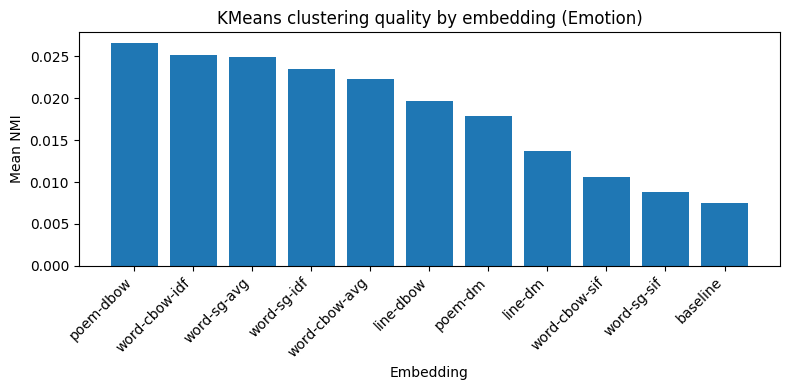

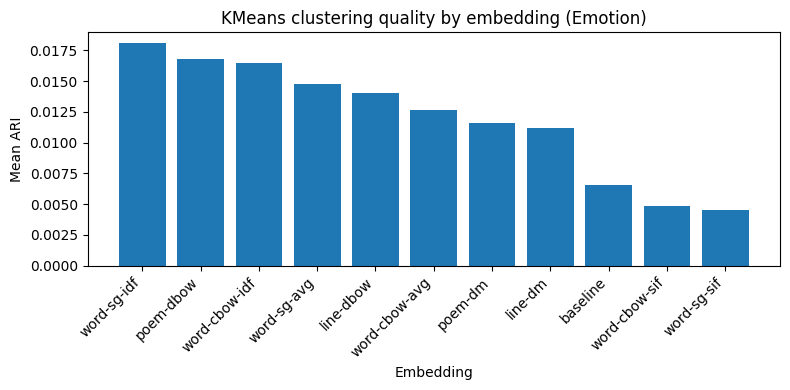

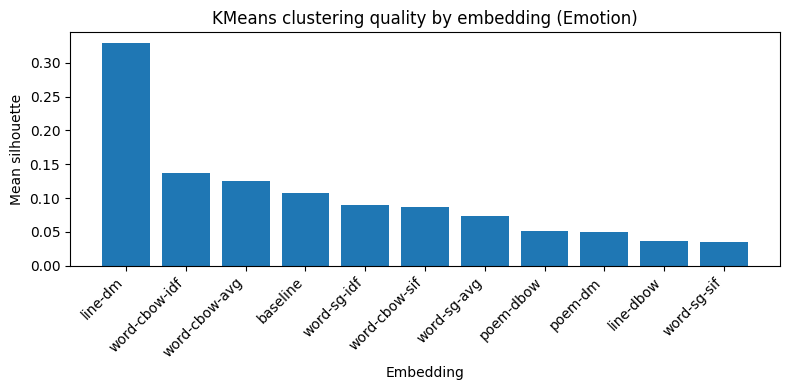

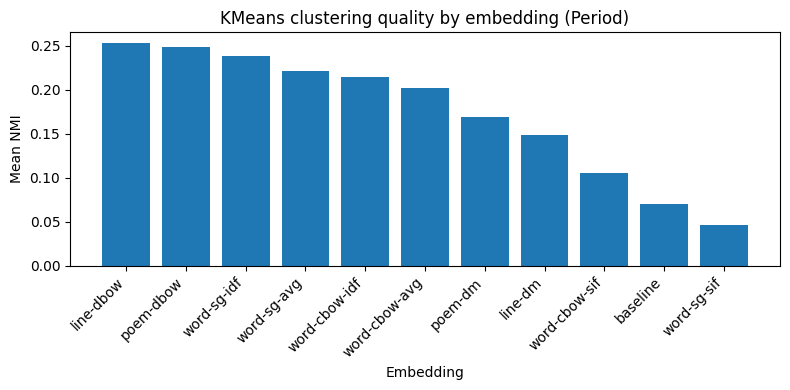

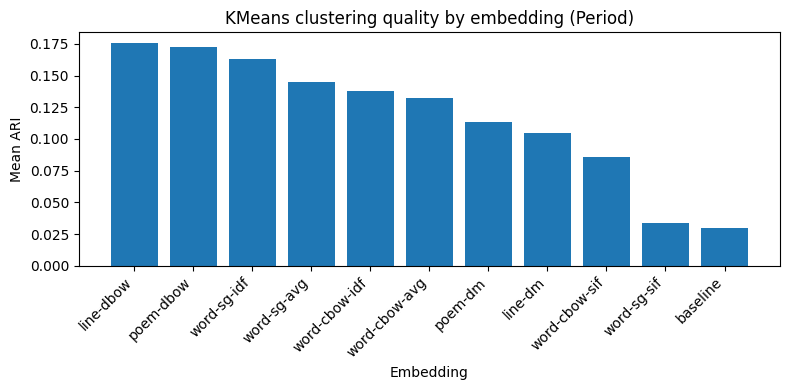

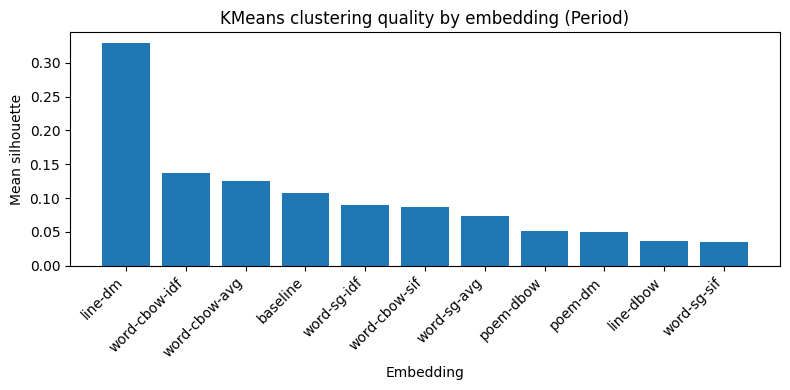

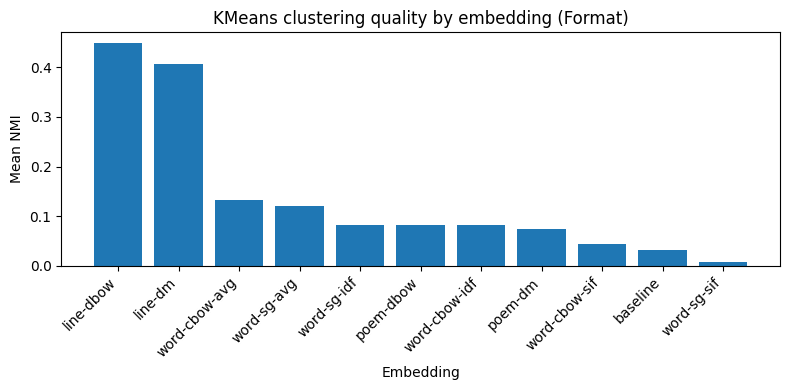

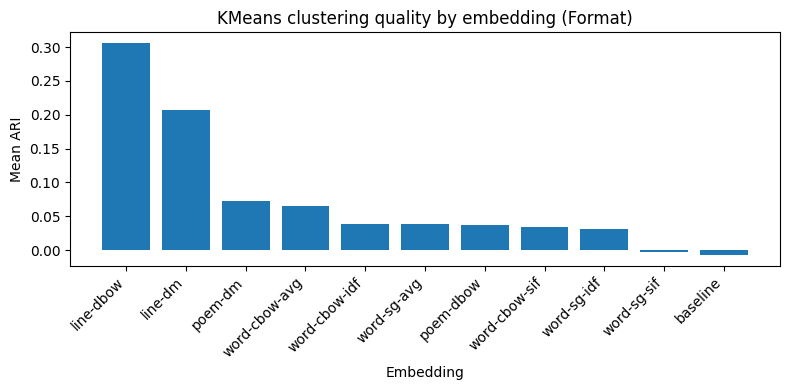

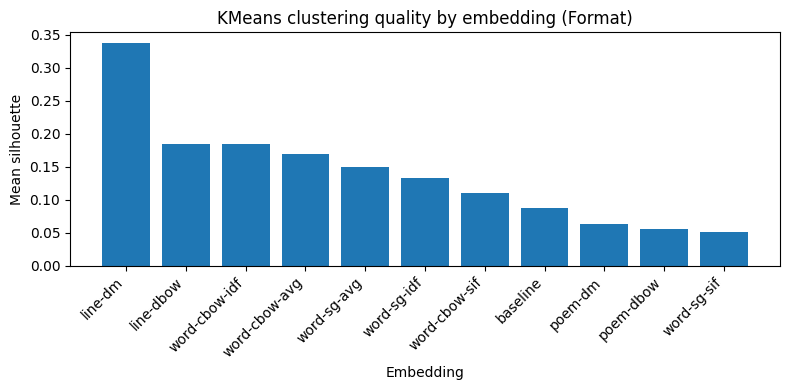

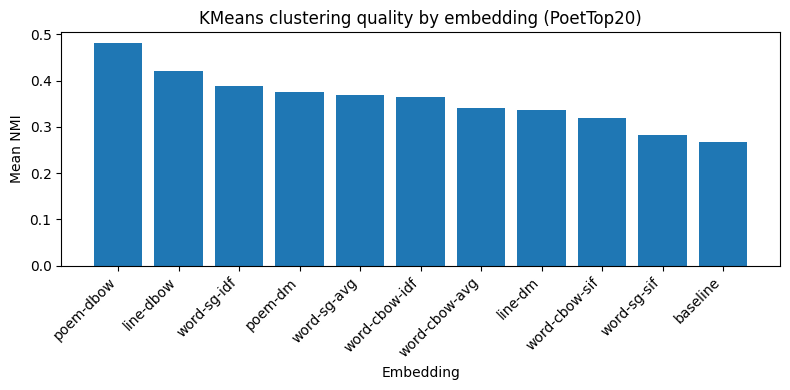

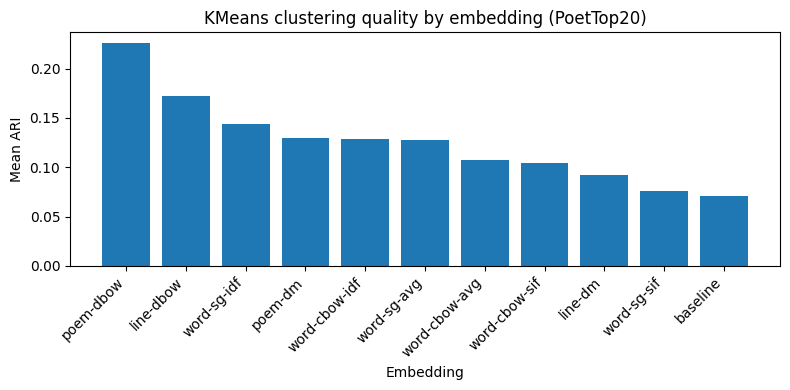

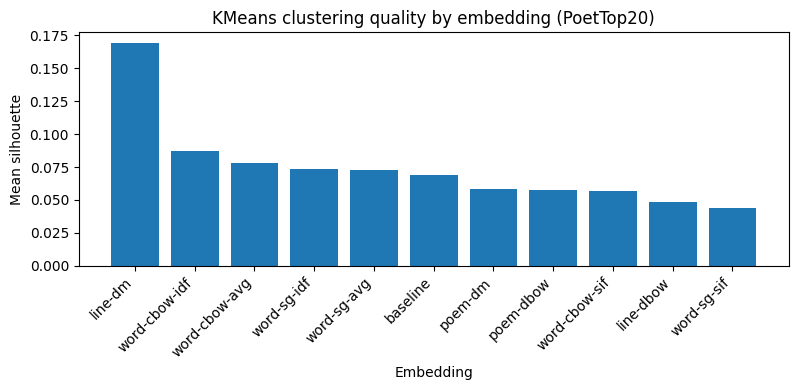

In [20]:
for task_name in ['Emotion', 'Period', 'Format', 'PoetTop20']:
    task_df = kmeans_summary[kmeans_summary['task'] == task_name].copy()

    nmi_df = task_df.sort_values('nmi_mean', ascending=False)
    plt.figure(figsize=(8, 4))
    plt.bar(nmi_df["embedding"].map(EMBEDDING_NAME_DICT), nmi_df['nmi_mean'])
    plt.xlabel('Embedding')
    plt.ylabel('Mean NMI')
    plt.title(f'KMeans clustering quality by embedding ({task_name})')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(figures_dir / f'fig_{task_name.lower()}_nmi.png', dpi=300)
    plt.show()

    ari_df = task_df.sort_values('ari_mean', ascending=False)
    plt.figure(figsize=(8, 4))
    plt.bar(ari_df['embedding'].map(EMBEDDING_NAME_DICT), ari_df['ari_mean'])
    plt.xlabel('Embedding')
    plt.ylabel('Mean ARI')
    plt.title(f'KMeans clustering quality by embedding ({task_name})')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(figures_dir / f'fig_{task_name.lower()}_ari.png', dpi=300)
    plt.show()

    silhouette_df = task_df.sort_values('silhouette_mean', ascending=False)
    plt.figure(figsize=(8, 4))
    plt.bar(silhouette_df['embedding'].map(EMBEDDING_NAME_DICT), silhouette_df['silhouette_mean'])
    plt.xlabel('Embedding')
    plt.ylabel('Mean silhouette')
    plt.title(f'KMeans clustering quality by embedding ({task_name})')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(figures_dir / f'fig_{task_name.lower()}_silhouette.png', dpi=300)
    plt.show()


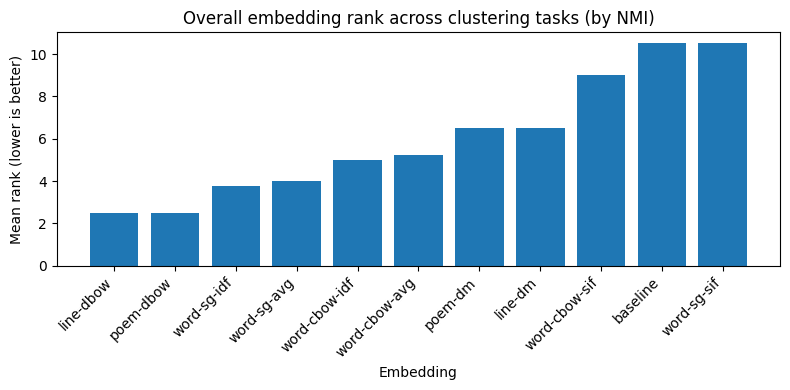

In [21]:
plt.figure(figsize=(8, 4))
plt.bar(ranking['embedding'].map(EMBEDDING_NAME_DICT), ranking['mean_nmi_rank'])
plt.xlabel('Embedding')
plt.ylabel('Mean rank (lower is better)')
plt.title('Overall embedding rank across clustering tasks (by NMI)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(figures_dir / 'fig_embedding_rank.png', dpi=300)
plt.show()


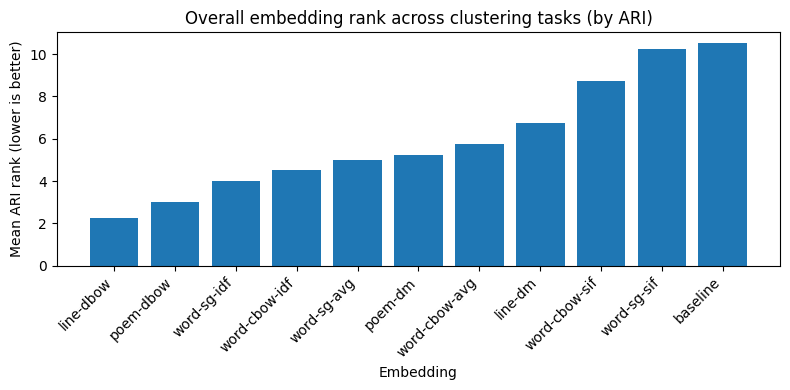

In [22]:
ranking2 = kmeans_summary.pivot(index='embedding', columns='task', values='ari_mean')
ranking2 = ranking2.rank(ascending=False, method='min').mean(axis=1).sort_values()
ranking2 = ranking2.rename('mean_ari_rank').reset_index()
ranking2.columns = ['embedding', 'mean_ari_rank']

plt.figure(figsize=(8, 4))
plt.bar(ranking2['embedding'].map(EMBEDDING_NAME_DICT), ranking2['mean_ari_rank'])
plt.xlabel('Embedding')
plt.ylabel('Mean ARI rank (lower is better)')
plt.title('Overall embedding rank across clustering tasks (by ARI)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(figures_dir / 'fig_embedding_rank_ari.png', dpi=300)
plt.show()

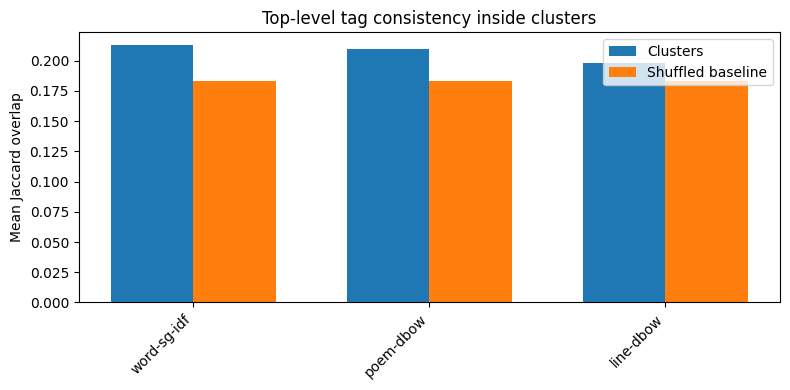

Saved figures:
results/cluster_analysis/figures/fig_emotion_nmi.png
results/cluster_analysis/figures/fig_period_nmi.png
results/cluster_analysis/figures/fig_poettop20_nmi.png
results/cluster_analysis/figures/fig_emotion_ari.png
results/cluster_analysis/figures/fig_period_ari.png
results/cluster_analysis/figures/fig_poettop20_ari.png
results/cluster_analysis/figures/fig_emotion_silhouette.png
results/cluster_analysis/figures/fig_period_silhouette.png
results/cluster_analysis/figures/fig_poettop20_silhouette.png
results/cluster_analysis/figures/fig_embedding_rank.png
results/cluster_analysis/figures/fig_tag_jaccard.png


In [23]:
x = np.arange(len(tag_jaccard_summary))
width = 0.35

plt.figure(figsize=(8, 4))
plt.bar(x - width / 2, tag_jaccard_summary['mean_within_cluster_jaccard'], width, label='Clusters')
plt.bar(x + width / 2, tag_jaccard_summary['baseline_mean_jaccard'], width, label='Shuffled baseline')
plt.xticks(x, tag_jaccard_summary['embedding'].map(EMBEDDING_NAME_DICT), rotation=45, ha='right')
plt.ylabel('Mean Jaccard overlap')
plt.title('Top-level tag consistency inside clusters')
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / 'fig_tag_jaccard.png', dpi=300)
plt.show()

print('Saved figures:')
for filename in [
    'fig_emotion_nmi.png',
    'fig_period_nmi.png',
    'fig_poettop20_nmi.png',
    'fig_emotion_ari.png',
    'fig_period_ari.png',
    'fig_poettop20_ari.png',
    'fig_emotion_silhouette.png',
    'fig_period_silhouette.png',
    'fig_poettop20_silhouette.png',
    'fig_embedding_rank.png',
    'fig_tag_jaccard.png',
]:
    print(figures_dir / filename)


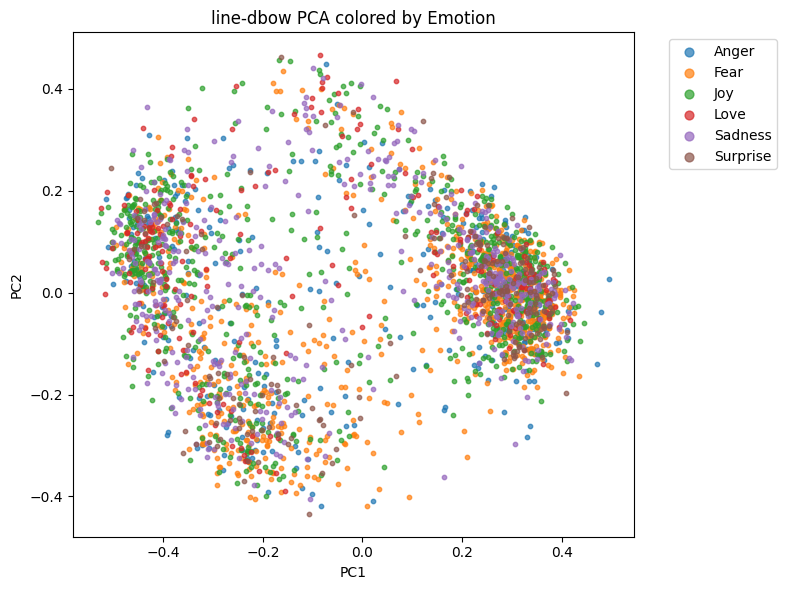

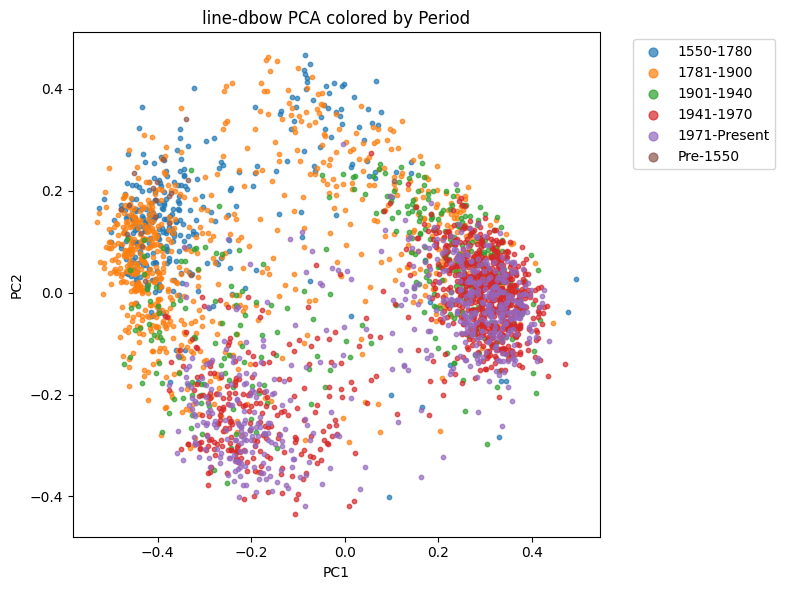

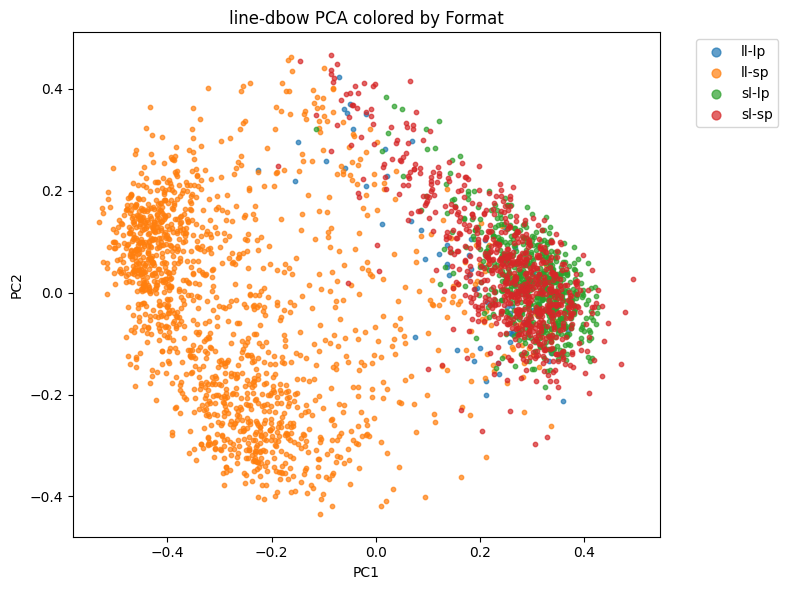

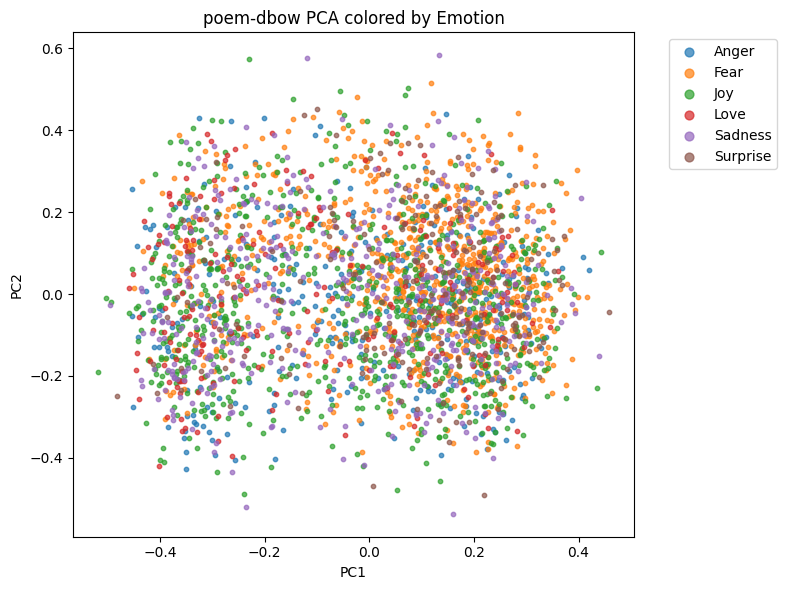

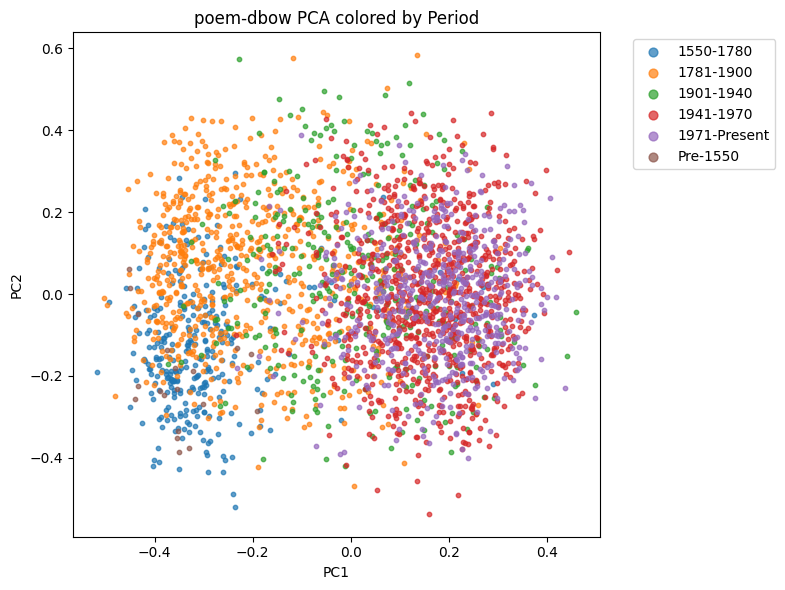

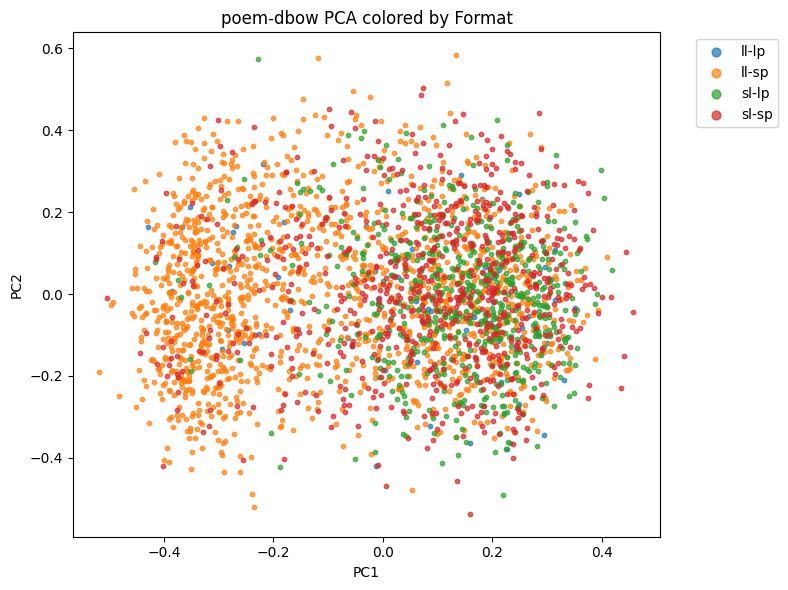

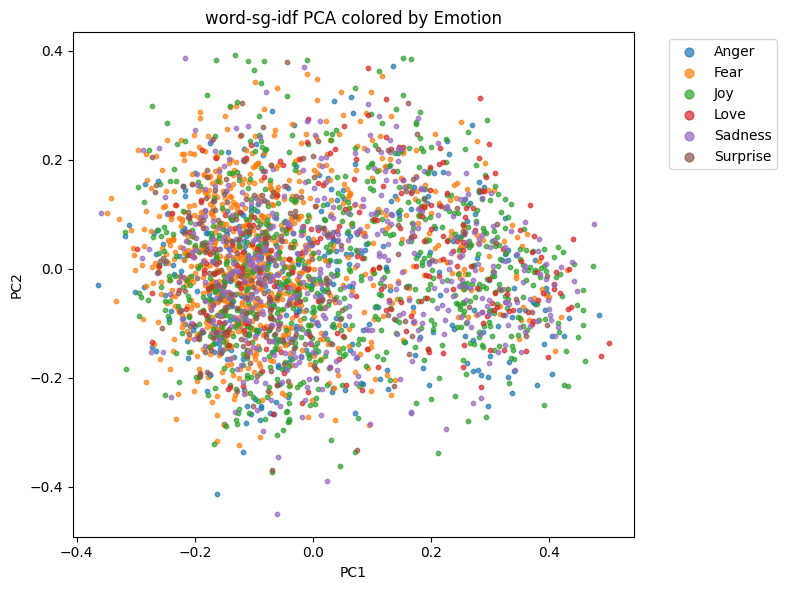

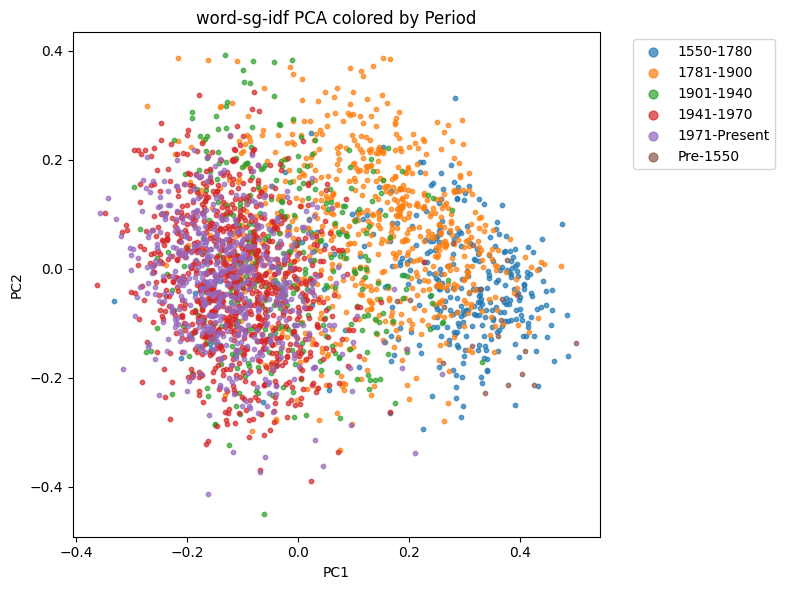

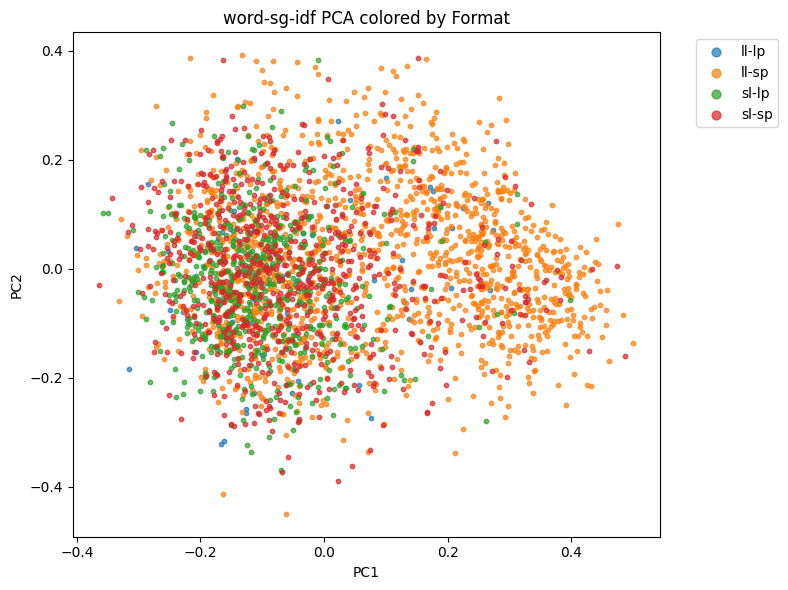

Saved PCA figures:
results/cluster_analysis/figures/fig_d2v_line_d100_w5_dbow_pca_emotion.png
results/cluster_analysis/figures/fig_d2v_line_d100_w5_dbow_pca_period.png
results/cluster_analysis/figures/fig_d2v_line_d100_w5_dbow_pca_format.png
results/cluster_analysis/figures/fig_d2v_poem_d100_w5_dbow_pca_emotion.png
results/cluster_analysis/figures/fig_d2v_poem_d100_w5_dbow_pca_period.png
results/cluster_analysis/figures/fig_d2v_poem_d100_w5_dbow_pca_format.png
results/cluster_analysis/figures/fig_w2v_d100_w5_sg_idf_pca_emotion.png
results/cluster_analysis/figures/fig_w2v_d100_w5_sg_idf_pca_period.png
results/cluster_analysis/figures/fig_w2v_d100_w5_sg_idf_pca_format.png


In [24]:
for embedding_name in best_embeddings:
    projection_path = projection_dir / f'{embedding_name}_pca_projection.csv'
    projection_df = pd.read_csv(projection_path)

    for label_column in ['Emotion', 'Period', 'Format']:
        plt.figure(figsize=(8, 6))
        for label, group in projection_df.groupby(label_column):
            plt.scatter(group['pc1'], group['pc2'], s=10, alpha=0.7, label=label)
        plt.xlabel('PC1')
        plt.ylabel('PC2')
        plt.title(f'{EMBEDDING_NAME_DICT[embedding_name]} PCA colored by {label_column}')
        plt.legend(markerscale=2, bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.savefig(figures_dir / f'fig_{embedding_name}_pca_{label_column.lower()}.png', dpi=300)
        plt.show()

print('Saved PCA figures:')
for embedding_name in best_embeddings:
    print(figures_dir / f'fig_{embedding_name}_pca_emotion.png')
    print(figures_dir / f'fig_{embedding_name}_pca_period.png')
    print(figures_dir / f'fig_{embedding_name}_pca_format.png')
